# Scenario Comparison

Run simulations across 5 scenarios to compare method performance under different data-generating conditions.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import SeedSequence

import methods as tm
from simulation import generate_dataset

In [ ]:
SCENARIOS = {
    "Baseline": {"price_tail": 1.0, "n_visits": 10, "summer_scale": 1.0, "precision_scale": 1.0},
    "CUPED-friendly": {"price_tail": 1.0, "n_visits": 20, "summer_scale": 1.0, "precision_scale": 0.5},
    "Stratification-friendly": {"price_tail": 1.0, "n_visits": 10, "summer_scale": 3.0, "precision_scale": 1.0},
    "Winsorization-friendly": {"price_tail": 3.0, "n_visits": 10, "summer_scale": 1.0, "precision_scale": 1.0},
    "Combined difficult": {"price_tail": 2.0, "n_visits": 20, "summer_scale": 2.0, "precision_scale": 0.5},
}

METHODS = [
    "ttest",
    "cuped",
    "strat",
    "wins",
    "wins+cuped",
    "wins+strat",
    "strat+cuped",
    "wins+strat+cuped",
]

N_SIMULATIONS = 1000
N_PER_GROUP = 5000

In [51]:
def run_methods(dataset):
    results = {}
    results["ttest"] = tm.ttest(df=dataset, split_feature="is_discount", feature="outcome")
    results["cuped"] = tm.cuped(df=dataset, split_feature="is_discount", pre_feature="outcome_pre", feature="outcome")
    results["strat"] = tm.stratification(df=dataset, split_feature="is_discount", feature="outcome", strat_feature="country")
    results["wins"] = tm.winsorize(df=dataset, split_feature="is_discount", feature="outcome")
    results["wins+cuped"] = tm.winsorized_cuped(df=dataset, split_feature="is_discount", feature="outcome", pre_feature="outcome_pre")
    results["wins+strat"] = tm.winsorized_stratification(df=dataset, split_feature="is_discount", feature="outcome", strat_feature="country")
    results["strat+cuped"] = tm.stratified_cuped(df=dataset, split_feature="is_discount", feature="outcome", pre_feature="outcome_pre", strat_feature="country")
    results["wins+strat+cuped"] = tm.winsorized_stratified_cuped(df=dataset, split_feature="is_discount", feature="outcome", pre_feature="outcome_pre", strat_feature="country")
    return results

In [52]:
DISCOUNT_SCALE_AA = 0.0
DISCOUNT_SCALE_AB = 0.2

master_seed = SeedSequence(42)
child_seeds = master_seed.spawn(N_SIMULATIONS)

all_results = {}

for scenario_name, params in SCENARIOS.items():
    for test_type, discount_scale in [("AA", DISCOUNT_SCALE_AA), ("AB", DISCOUNT_SCALE_AB)]:
        key = f"{scenario_name} | {test_type}"
        print(f"Running: {key}")
        rejections = {m: 0 for m in METHODS}
        ci_widths = {m: [] for m in METHODS}

        for seed in child_seeds:
            dataset = generate_dataset(
                n_per_group=N_PER_GROUP,
                seed=seed,
                summer_scale=params["summer_scale"],
                discount_scale=discount_scale,
                precision_scale=params["precision_scale"],
                price_tail=params["price_tail"],
                n_visits=params["n_visits"],
            )
            results = run_methods(dataset)
            for m in METHODS:
                ci_w, reject = results[m]
                ci_widths[m].append(ci_w)
                rejections[m] += reject

        all_results[key] = {
            "test_type": test_type,
            "scenario": scenario_name,
            "rejection_rate": {m: rejections[m] / N_SIMULATIONS for m in METHODS},
            "mean_ci_width": {m: np.mean(ci_widths[m]) for m in METHODS},
        }
        print(f"  Done.")

Running: Baseline | AA
  Done.
Running: Baseline | AB
  Done.
Running: CUPED-friendly | AA
  Done.
Running: CUPED-friendly | AB
  Done.
Running: Stratification-friendly | AA
  Done.
Running: Stratification-friendly | AB
  Done.
Running: Winsorization-friendly | AA
  Done.
Running: Winsorization-friendly | AB
  Done.
Running: Combined difficult | AA
  Done.
Running: Combined difficult | AB
  Done.


## Results

In [53]:
rows = []
for key, data in all_results.items():
    for method in METHODS:
        rows.append({
            "Scenario": data["scenario"],
            "Test": data["test_type"],
            "Method": method,
            "Rejection Rate": data["rejection_rate"][method],
            "Mean CI Width": data["mean_ci_width"][method],
        })

results_df = pd.DataFrame(rows)
results_df

,Scenario,Test,Method,Rejection Rate,Mean CI Width
0,Baseline,AA,ttest,0.050,117.850502
1,Baseline,AA,cuped,0.052,114.210790
2,Baseline,AA,strat,0.048,114.929499
3,Baseline,AA,wins,0.052,113.727882
4,Baseline,AA,wins+cuped,0.050,110.143939
...,...,...,...,...,...
75,Combined difficult,AB,wins,0.883,379.240017
76,Combined difficult,AB,wins+cuped,0.939,338.911808
77,Combined difficult,AB,wins+strat,0.896,369.111233
78,Combined difficult,AB,strat+cuped,0.961,341.183405


In [54]:
aa_df = results_df[results_df["Test"] == "AA"]
ab_df = results_df[results_df["Test"] == "AB"]

pivot_ci_aa = aa_df.pivot(index="Method", columns="Scenario", values="Mean CI Width").reindex(METHODS)[list(SCENARIOS.keys())]
pivot_ci_ab = ab_df.pivot(index="Method", columns="Scenario", values="Mean CI Width").reindex(METHODS)[list(SCENARIOS.keys())]

pivot_ci_aa_rel = pivot_ci_aa.div(pivot_ci_aa.loc["ttest"])
pivot_ci_ab_rel = pivot_ci_ab.div(pivot_ci_ab.loc["ttest"])

print("AA — Relative CI Width (vs t-test)")
display(pivot_ci_aa_rel)
print("\nAB — Relative CI Width (vs t-test)")
display(pivot_ci_ab_rel)

AA — Relative CI Width (vs t-test)


Scenario,Baseline,CUPED-friendly,Stratification-friendly,Winsorization-friendly,Combined difficult
Method,,,,,
ttest,1.000000,1.000000,1.000000,1.000000,1.000000
cuped,0.969116,0.846649,0.970892,0.969116,0.894501
strat,0.975214,0.968853,0.966597,0.975214,0.974265
wins,0.965018,0.972596,0.971829,0.965018,0.975203
wins+cuped,0.934607,0.822496,0.942981,0.934607,0.871849
wins+strat,0.940284,0.941560,0.938388,0.940284,0.949481
strat+cuped,0.955033,0.838925,0.943186,0.955033,0.881995
wins+strat+cuped,0.920472,0.814605,0.915251,0.920472,0.859262



AB — Relative CI Width (vs t-test)


Scenario,Baseline,CUPED-friendly,Stratification-friendly,Winsorization-friendly,Combined difficult
Method,,,,,
ttest,1.000000,1.000000,1.000000,1.000000,1.000000
cuped,0.968752,0.846023,0.970648,0.968752,0.894189
strat,0.974523,0.968188,0.966203,0.974523,0.973820
wins,0.971033,0.977879,0.977305,0.971033,0.980255
wins+cuped,0.940143,0.826308,0.948127,0.940143,0.876015
wins+strat,0.945590,0.946140,0.943461,0.945590,0.954075
strat+cuped,0.954567,0.838657,0.942920,0.954567,0.881887
wins+strat+cuped,0.925861,0.818720,0.920350,0.925861,0.863597


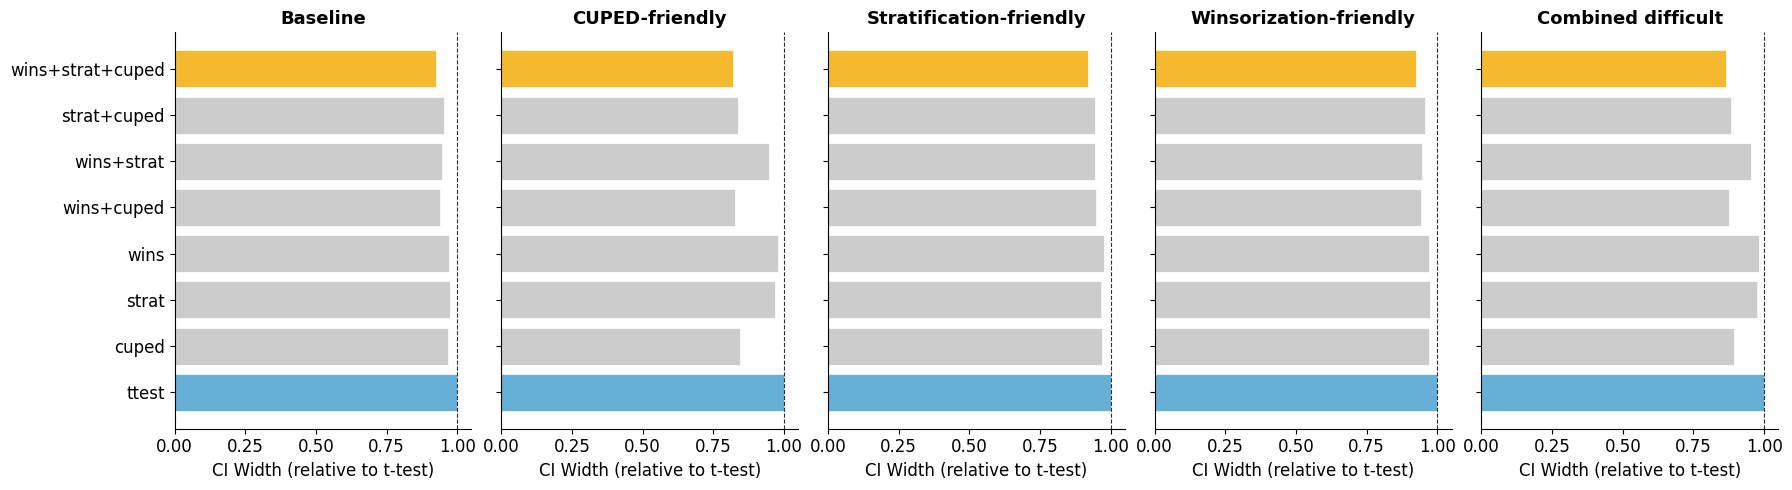

In [61]:
plt.style.use('seaborn-v0_8-muted')

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(18, 5), sharey=True)

for col, scenario_name in enumerate(SCENARIOS):
    ax = axes[col]
    widths = pivot_ci_ab_rel[scenario_name]
    colors = ['#66afd5' if v == 1.0 else '#f3ba30' if v == widths.min() else '#cccccc' for v in widths]
    ax.barh(widths.index, widths.values, color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(1.0, color="#2d2d2d", linestyle="--", linewidth=0.8)
    ax.set_title(f"{scenario_name}", fontsize=13, fontweight="bold")
    ax.tick_params(axis='both', labelsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("CI Width (relative to t-test)", fontsize=12)

plt.tight_layout()
plt.show()

In [56]:
pivot_fpr = aa_df.pivot(index="Method", columns="Scenario", values="Rejection Rate").reindex(METHODS)[list(SCENARIOS.keys())]
pivot_power = ab_df.pivot(index="Method", columns="Scenario", values="Rejection Rate").reindex(METHODS)[list(SCENARIOS.keys())]

print("AA — False Positive Rate (should be ~0.05)")
display(pivot_fpr)
print("\nAB — Power (rejection rate under true effect)")
display(pivot_power)

AA — False Positive Rate (should be ~0.05)


Scenario,Baseline,CUPED-friendly,Stratification-friendly,Winsorization-friendly,Combined difficult
Method,,,,,
ttest,0.050,0.055,0.047,0.050,0.047
cuped,0.052,0.053,0.058,0.052,0.052
strat,0.048,0.057,0.056,0.048,0.054
wins,0.052,0.058,0.048,0.052,0.048
wins+cuped,0.050,0.055,0.053,0.050,0.054
wins+strat,0.055,0.055,0.047,0.055,0.049
strat+cuped,0.053,0.050,0.050,0.053,0.048
wins+strat+cuped,0.049,0.054,0.050,0.049,0.049



AB — Power (rejection rate under true effect)


Scenario,Baseline,CUPED-friendly,Stratification-friendly,Winsorization-friendly,Combined difficult
Method,,,,,
ttest,0.779,0.878,0.945,0.779,0.911
cuped,0.815,0.958,0.957,0.815,0.955
strat,0.790,0.900,0.954,0.790,0.913
wins,0.750,0.855,0.936,0.750,0.883
wins+cuped,0.779,0.947,0.950,0.779,0.939
wins+strat,0.760,0.877,0.946,0.760,0.896
strat+cuped,0.810,0.964,0.968,0.810,0.961
wins+strat+cuped,0.778,0.955,0.965,0.778,0.949
